In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import io
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
import pandas as pd
import io
from google.colab import files

print("Por favor, suba o arquivo 'Gastos_Publicidade_MelhoresCompras.csv' abaixo:")
uploaded = files.upload()

nome_arquivo = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[nome_arquivo]))

if df['Gastos com Publicidade (em R$)'].dtype == 'O':
    df['Gastos com Publicidade (em R$)'] = df['Gastos com Publicidade (em R$)'].str.replace(',', '.').astype(float)

print(f"Arquivo {nome_arquivo} carregado com sucesso!")
df.head()

Por favor, suba o arquivo 'Gastos_Publicidade_MelhoresCompras.csv' abaixo:


Saving Gastos_Publicidade_MelhoresCompras.csv to Gastos_Publicidade_MelhoresCompras.csv
Arquivo Gastos_Publicidade_MelhoresCompras.csv carregado com sucesso!


,Ano,Mes,Tipo de Midia,Gastos com Publicidade (em R$),Previsao Inicial de Aumento de Vendas (em mil unidades)
0,2022,1,Paginas web,87000.0,1000
1,2022,1,Redes sociais,120000.0,800
2,2022,1,TV,250000.0,1500
3,2022,1,Jornal,110000.0,730
4,2022,1,Revista,40000.0,360


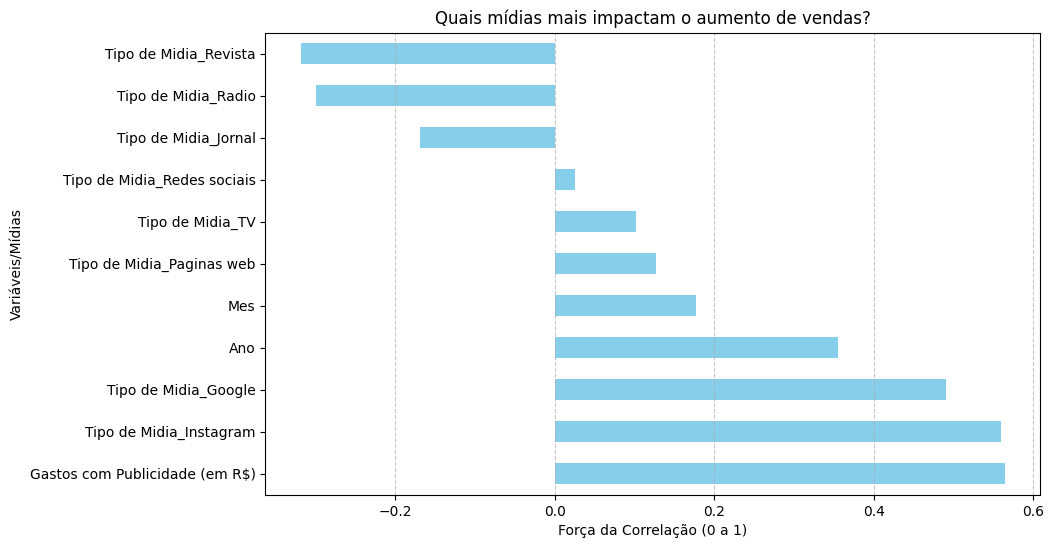

In [3]:
import matplotlib.pyplot as plt

df_modelo = pd.get_dummies(df, columns=['Tipo de Midia'])
correlacao_alvo = df_modelo.corr()['Previsao Inicial de Aumento de Vendas (em mil unidades)'].sort_values(ascending=False)
correlacao_alvo = correlacao_alvo.drop('Previsao Inicial de Aumento de Vendas (em mil unidades)')

plt.figure(figsize=(10, 6))
correlacao_alvo.plot(kind='barh', color='skyblue')
plt.title('Quais mídias mais impactam o aumento de vendas?')
plt.xlabel('Força da Correlação (0 a 1)')
plt.ylabel('Variáveis/Mídias')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

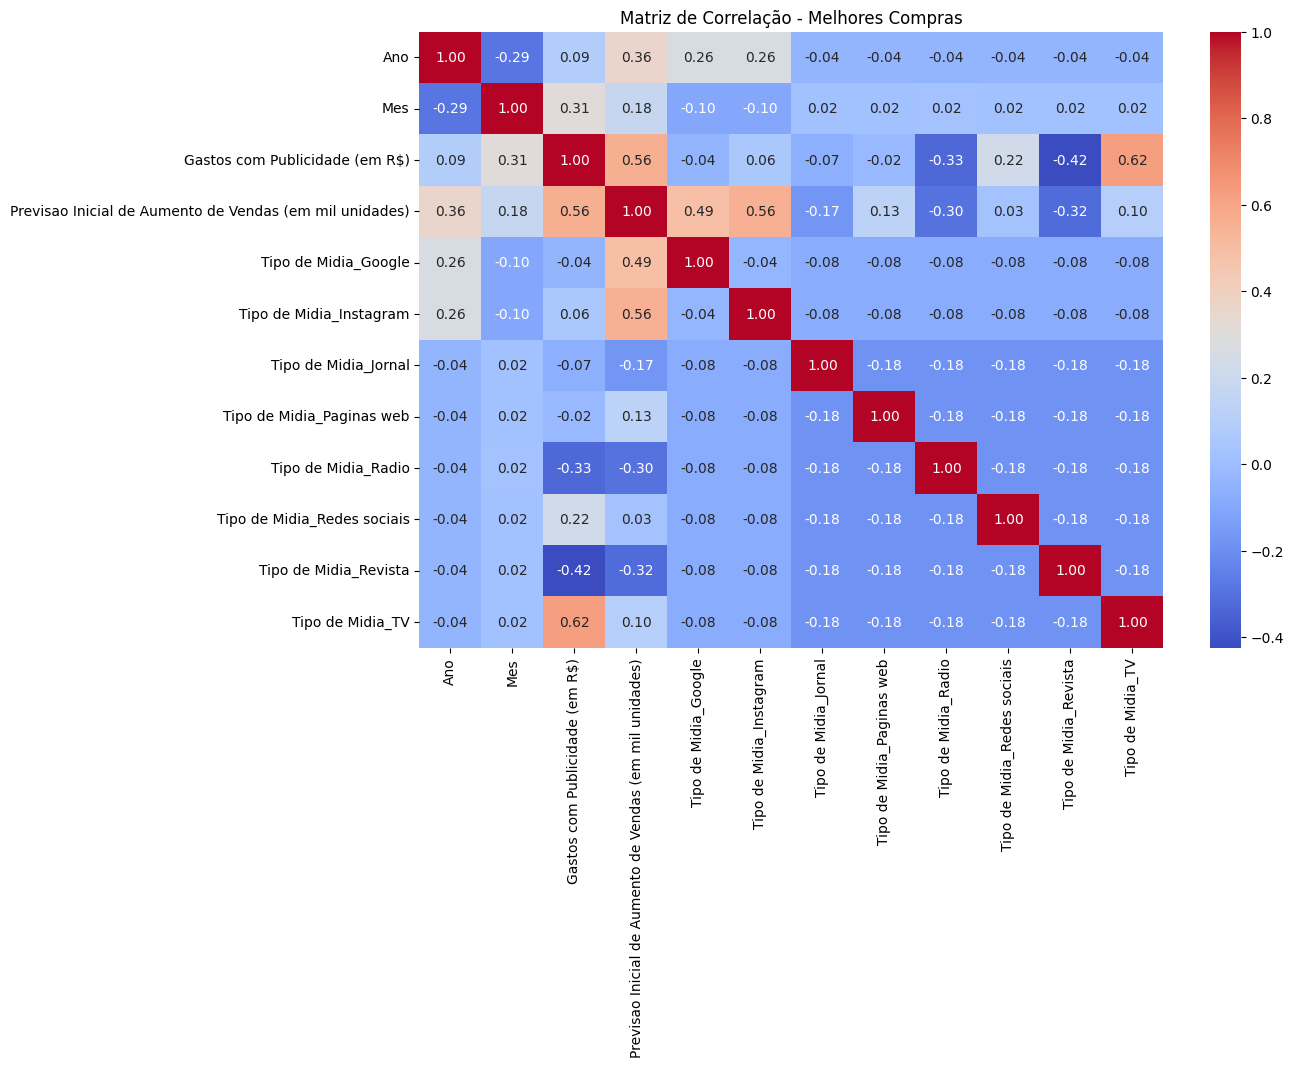

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df_modelo.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação - Melhores Compras')
plt.show()

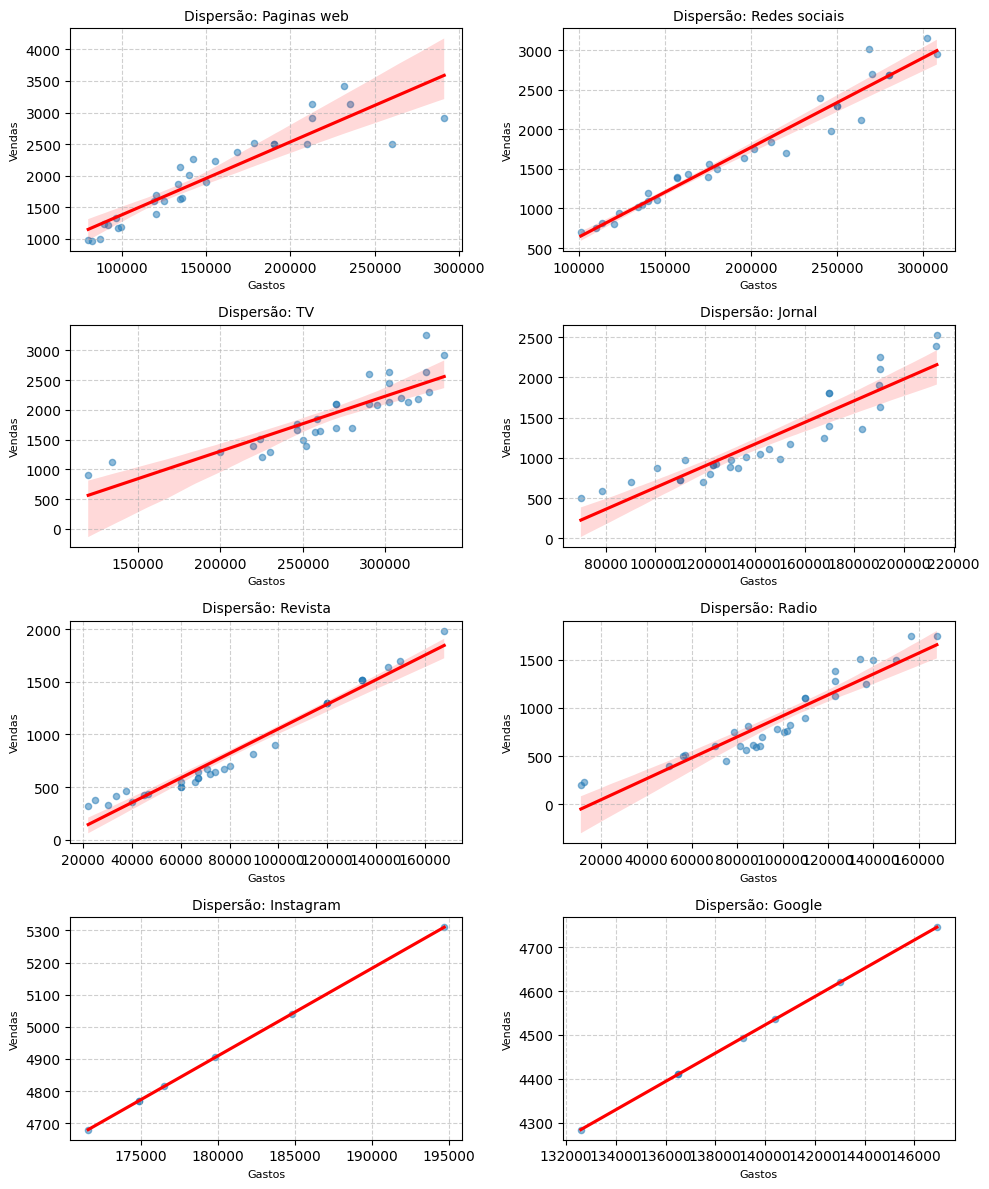

In [5]:
midias = df['Tipo de Midia'].unique()
plt.figure(figsize=(10, 12))

for i, midia in enumerate(midias, 1):
    plt.subplot(4, 2, i)
    dados_midia = df[df['Tipo de Midia'] == midia]

    sns.regplot(data=dados_midia, x='Gastos com Publicidade (em R$)',
                y='Previsao Inicial de Aumento de Vendas (em mil unidades)',
                scatter_kws={'alpha':0.5, 's':20},
                line_kws={'color':'red'})

    plt.title(f'Dispersão: {midia}', fontsize=10)
    plt.xlabel('Gastos', fontsize=8)
    plt.ylabel('Vendas', fontsize=8)
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df_modelo.drop(['Previsao Inicial de Aumento de Vendas (em mil unidades)', 'Ano', 'Mes'], axis=1)
y = df_modelo['Previsao Inicial de Aumento de Vendas (em mil unidades)']
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_treino, y_treino)
previsoes = modelo.predict(X_teste)
r2 = r2_score(y_teste, previsoes)

print(f"O R² do modelo é: {r2:.4f}")
coeficientes = pd.DataFrame(modelo.coef_, X.columns, columns=['Peso/Impacto'])
print("\nImpacto de cada mídia no modelo:")
print(coeficientes.sort_values(by='Peso/Impacto', ascending=False))

O R² do modelo é: 0.9678

Impacto de cada mídia no modelo:
                                Peso/Impacto
Tipo de Midia_Google             2459.353892
Tipo de Midia_Instagram          2402.469017
Gastos com Publicidade (em R$)      0.011362
Tipo de Midia_Paginas web        -200.869172
Tipo de Midia_Revista            -551.790210
Tipo de Midia_Radio              -676.807023
Tipo de Midia_Jornal             -873.802389
Tipo de Midia_Redes sociais      -971.707079
Tipo de Midia_TV                -1586.847036


Relatorio de Analise de Marketing

1. Resultados do Modelo
O modelo de regressao que a gente fez teve um R2 de 0,9678. Quer dizer que quase tudo que acontece nas vendas foi explicado pelos gastos que a gente analisou. Com essa precisao de quase 97%, da para confiar muito nos resultados para tomar decisao.

2. O que a gente descobriu:

Google e Instagram: Sao os canais que mais dao resultado de verdade. O peso deles no aumento das vendas e muito maior que os outros.

TV, Radio e Jornal: Tem um retorno bem menor. O dinheiro gasto neles nao faz as vendas subirem na mesma velocidade que o digital.

3. Sugestão para o Marketing
A nossa recomendaçao é tirar um pouco do dinheiro parado em mídias tradicionais (TV e Jornal) e colocar mais verba no Instagram e no Google. Como o modelo mostrou que esses sao os pontos fortes, a empresa vai conseguir vender mais gastando a mesma coisa.